This notebook is only to see the catboost regressor of the RNAseq z-score combat (withour ridge)

In [1]:
import pandas as pd
from ydata_profiling import ProfileReport
import getting_threshold_genes as gtg
from sklearn.model_selection import train_test_split
import model as m
import divide_bins as divide
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error
import optuna
from sklearn.metrics import accuracy_score
from sklearn.metrics import matthews_corrcoef
from ydata_profiling import ProfileReport
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns
from catboost import CatBoostClassifier
import shap
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score
import feature_selection as fs
import pickle

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-05-27 14:46:59.271046: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-27 14:46:59.272658: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-27 14:46:59.279874: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-27 14:46:59.308000: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register

In [2]:
fit=False
testing_size='40'
testing_size_f=0.40

In [3]:
#eigth_bins = pd.read_csv("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_2_train.csv")
eigth_bins = pd.read_csv("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Data/RNAseq_Combat_z_score_Train_set_SMOTE_noise.csv")
eigth_bins.head()

,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,ENSG00000001167.14,...,ENSG00000285470.1,ENSG00000285471.1,ENSG00000285472.1,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Age
0,-0.027742,-0.032481,0.000939,-0.029697,-0.029711,-0.031883,-0.022563,-0.028709,-0.023524,-0.027502,...,-0.032549,-0.032346,-0.032538,-0.032025,-0.031420,-0.032510,-0.032550,-0.029729,-0.032295,75.0
1,-0.018289,-0.024834,-0.002716,-0.023411,-0.023441,-0.024564,-0.019551,-0.022235,-0.020411,-0.022674,...,-0.024891,-0.024734,-0.024860,-0.024787,-0.024783,-0.024865,-0.024898,-0.027481,-0.024701,85.0
2,-0.023552,-0.027343,-0.007636,-0.025816,-0.025592,-0.026353,-0.021507,-0.020810,-0.022853,-0.023725,...,-0.027358,-0.027431,-0.027354,-0.027349,-0.026726,-0.027418,-0.027347,-0.025376,-0.026991,51.0
3,-0.029005,-0.033401,0.000583,-0.028778,-0.029956,-0.033116,-0.027197,-0.028614,-0.024847,-0.028604,...,-0.033467,-0.033467,-0.033456,-0.033327,-0.031928,-0.033431,-0.033467,-0.030221,-0.033333,71.0
4,-0.025443,-0.030270,-0.001806,-0.026169,-0.027979,-0.029679,-0.021693,-0.026117,-0.022741,-0.024588,...,-0.030232,-0.030294,-0.030216,-0.030203,-0.027980,-0.030294,-0.030219,-0.029668,-0.029403,55.0


In [4]:
eigth_bins_filteres = eigth_bins#[rnaseq_genes]


In [5]:
len(eigth_bins_filteres)

230

In [6]:
del eigth_bins

In [7]:
seq_y_train_cat_a=eigth_bins_filteres["Age"]
seq_y_train_a = pd.Series(seq_y_train_cat_a)



dataset = eigth_bins_filteres.copy()
dataset["Age"]=seq_y_train_a
dataset.head()

,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,ENSG00000001167.14,...,ENSG00000285470.1,ENSG00000285471.1,ENSG00000285472.1,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Age
0,-0.027742,-0.032481,0.000939,-0.029697,-0.029711,-0.031883,-0.022563,-0.028709,-0.023524,-0.027502,...,-0.032549,-0.032346,-0.032538,-0.032025,-0.031420,-0.032510,-0.032550,-0.029729,-0.032295,75.0
1,-0.018289,-0.024834,-0.002716,-0.023411,-0.023441,-0.024564,-0.019551,-0.022235,-0.020411,-0.022674,...,-0.024891,-0.024734,-0.024860,-0.024787,-0.024783,-0.024865,-0.024898,-0.027481,-0.024701,85.0
2,-0.023552,-0.027343,-0.007636,-0.025816,-0.025592,-0.026353,-0.021507,-0.020810,-0.022853,-0.023725,...,-0.027358,-0.027431,-0.027354,-0.027349,-0.026726,-0.027418,-0.027347,-0.025376,-0.026991,51.0
3,-0.029005,-0.033401,0.000583,-0.028778,-0.029956,-0.033116,-0.027197,-0.028614,-0.024847,-0.028604,...,-0.033467,-0.033467,-0.033456,-0.033327,-0.031928,-0.033431,-0.033467,-0.030221,-0.033333,71.0
4,-0.025443,-0.030270,-0.001806,-0.026169,-0.027979,-0.029679,-0.021693,-0.026117,-0.022741,-0.024588,...,-0.030232,-0.030294,-0.030216,-0.030203,-0.027980,-0.030294,-0.030219,-0.029668,-0.029403,55.0


In [8]:
class optimize:
    def __init__(self,train_data, n_trials=50):
        X_train, X_test, y_train, y_test, _, _ = m.divide_test_train_dataset(train_data, test_size=testing_size_f)
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test
        self.n_trials = n_trials
    def optimize(self):
        study = optuna.create_study(direction='minimize')  # Maximize accuracy
        study.optimize(self.objective, n_trials=self.n_trials) 
    def objective(self, trial):
        # Define hyperparameters to optimize
        params = {
            'iterations': trial.suggest_int('iterations', 50, 1000),
            'learning_rate': trial.suggest_loguniform('learning_rate', 0.001, 0.01),
            'depth': trial.suggest_int('depth', 2, 5),
            'random_state': 42,  # Fixed random state
            'verbose': 0,  # Fixed verbosity
            'od_type': 'Iter',  # Early stopping type
            'od_wait': 5,  # Early stopping patience
            #'eval_metric': 'RMSE'  # Metric to optimize

        }
        params = {
        'iterations': trial.suggest_int('iterations', 50, 100),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.001, 0.01),
        'depth': trial.suggest_int('depth', 2, 5),  # Modify depth range to match the original
        'verbose': 0,  # Fixed verbosity
        'od_type': 'Iter',  # Early stopping type
        'od_wait': 5,  # Early stopping patience
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 0.0, 10.0),  # L2 regularization coefficient
        #'sampling_frequency': trial.suggest_categorical('sampling_frequency', ['PerTree', 'PerTreeLevel', 'PerTreeNode']),  # Frequency of sampling
        'random_strength': trial.suggest_float('random_strength', 0.0, 10.0),  # Random strength
        #'grow_policy': trial.suggest_categorical('grow_policy', ['SymmetricTree', 'Depthwise', 'Lossguide']),  # Tree growth policy
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 100),  # Minimum number of samples in leaf
        #'boosting_type': trial.suggest_categorical('boosting_type', ['Ordered', 'Plain']),  # Type of boosting
        'score_function': trial.suggest_categorical('score_function', ['Cosine', 'L2']),  # Metric to use
        'penalties_coefficient': trial.suggest_float('penalties_coefficient', 0.0, 10.0),  # Penalty coefficient
        'model_shrink_rate': trial.suggest_float('model_shrink_rate', 0.0, 1.0),  # Model shrink rate
        #'model_shrink_mode': trial.suggest_categorical('model_shrink_mode', ['Constant', 'ShrinkToBest', 'ShrinkToRandom']),  # Model shrink mode
        'eval_metric': 'RMSE'  # Metric to optimize
    }

        # Initialize classifier with the suggested hyperparameters
        regressor = CatBoostRegressor(**params)

        # Fit the model
        regressor.fit(self.X_train, self.y_train, eval_set=(self.X_test, self.y_test), use_best_model=True)
        # Make predictions
        y_pred = regressor.predict(self.X_test)
        # Calculate rmse
        rmse = mean_squared_error(self.y_test, y_pred, squared=False)
        return rmse


In [9]:

if fit:
    optimize = optimize(train_data = dataset, n_trials=20)
    params = optimize.optimize()
    params

In [10]:
# [I 2024-09-25 21:18:19,700] Trial 6 finished with value: 4.733188762255442 and parameters: 
params = {'iterations': 556, 'learning_rate': 0.008352826387919279, 'depth': 3, 'l2_leaf_reg': 8.625993928282805, 'random_strength': 5.518222301454832, 'min_data_in_leaf': 37, 'score_function': 'L2', 'penalties_coefficient': 0.9978892027428243, 'model_shrink_rate': 0.03029125396360066}
#. Best is trial 6 with value: 4.733188762255442.


In [11]:
#

In [12]:
#params = {'iterations': 2000, 'learning_rate': 0.0057754728847108075, 'depth': 4, 'l2_leaf_reg': 1.4995313057538833, 'random_strength': 3.6144926272336773, 'min_data_in_leaf': 33, 'score_function': 'Cosine', 'penalties_coefficient': 7.492437722110218, 'model_shrink_rate': 0.0036095159058368662}

In [13]:
#fit=True


In [14]:
X_train, X_test, y_train, y_test, _, _ = m.divide_test_train_dataset(dataset, test_size=testing_size_f)
#random_strength

# Initialize CatBoostClassifier
seq_regressor = CatBoostRegressor(**params) 

# Fit the model
if fit:
    seq_regressor.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True, plot=False)

In [15]:
if fit:
    # Specify the file path where you want to save the pickle file
    file_path = f'/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/models/RNAs_z_Combat_7_SMOTE_seq_regressor_556i_{testing_size}.pkl'

    # Save the seq_regressor variable in the pickle file
    with open(file_path, 'wb') as f:
        pickle.dump(seq_regressor, f)
else:

    # Specify the file path where the pickle file is located
    file_path = f'/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/models/RNAs_z_Combat_7_SMOTE_seq_regressor_556i_{testing_size}.pkl'

    # Load the seq_regressor object from the pickle file
    with open(file_path, 'rb') as f:
        seq_regressor = pickle.load(f)

    # Now you can use the seq_regressor object in your code


In [16]:
# Make predictions
y_pred = seq_regressor.predict(X_test)

# Evaluate mean squared error
seq_mse = mean_squared_error(y_test, y_pred)
seq_results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
seq_mse

49.135814287356936

In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_auc_score
import numpy as np

# Calculate AUC
# Assuming y_test and y_pred are appropriate for AUC calculation (e.g., binary classification)
# auc = roc_auc_score(y_test, y_pred)

# Calculate MSE
mse = mean_squared_error(y_test, y_pred)

# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)

# Calculate R2
r2 = r2_score(y_test, y_pred)

print("Metrics:")
# print("AUC:", auc)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)


Metrics:
MSE: 49.135814287356936
RMSE: 7.009694307696801
MAE: 4.982715763400889
R2: 0.907674221379969


In [18]:
age_ranges_list=[18, 26, 35, 65, 71,72, 95]
age_ranges = fs.get_age_distribution(y_test, age_ranges=age_ranges_list)
age_ranges

[{'label': '18-26', 'range': (18, 26), 'count': 18},
 {'label': '26-35', 'range': (26, 35), 'count': 19},
 {'label': '35-65', 'range': (35, 65), 'count': 18},
 {'label': '65-71', 'range': (65, 71), 'count': 6},
 {'label': '71-72', 'range': (71, 72), 'count': 5},
 {'label': '72-95', 'range': (72, 95), 'count': 26}]

In [19]:
c_y_test = pd.Series(y_test).apply(lambda x: divide.assign_age_group(x, age_ranges))
c_y_pred = pd.Series(y_pred).apply(lambda x: divide.assign_age_group(x, age_ranges))
arr_confusion_matrix = confusion_matrix(c_y_test, c_y_pred)
arr_confusion_matrix

array([[16,  2,  0,  0,  0,  0],
       [ 4, 11,  4,  0,  0,  0],
       [ 0,  0, 18,  0,  0,  0],
       [ 0,  0,  1,  4,  1,  0],
       [ 0,  0,  0,  5,  0,  0],
       [ 0,  0,  5,  8,  0, 13]])

In [20]:
seq_auc=accuracy_score(c_y_test.round(0), c_y_pred.round(0))
seq_auc

0.6739130434782609

In [21]:
mcc = matthews_corrcoef(c_y_test, c_y_pred)
mcc

0.6205012028058942

In [22]:
y_test

70     23.0
99     84.0
207    54.0
197    27.0
103    54.0
       ... 
166    24.0
158    54.0
54     22.0
94     82.0
182    29.0
Name: Age, Length: 92, dtype: float64

In [23]:
seq_results

,Actual,Predicted
70,23.0,24.452858
99,84.0,76.907818
207,54.0,50.676285
197,27.0,29.115051
103,54.0,58.668031
...,...,...
166,24.0,23.926397
158,54.0,51.389890
54,22.0,27.010826
94,82.0,64.860386


In [24]:
seq_results.to_csv(f"/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_7_SMOTE_seq_results_testset_556i_{testing_size}.csv")

/tmp/ipykernel_112440/528406118.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='Actual', y='Predicted', data=seq_results, palette='Set1', alpha=0.8, edgecolor='w')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


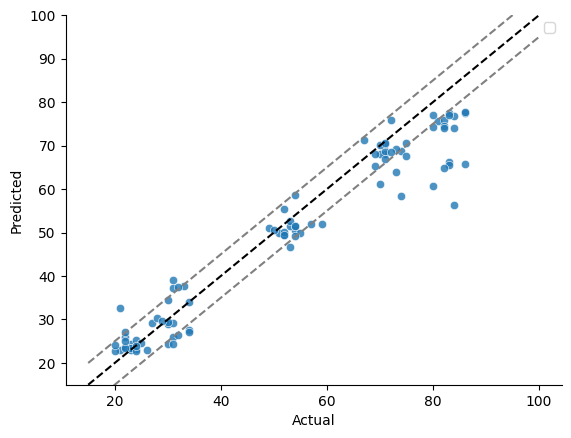

In [25]:
# Your existing scatter plot code
sns.scatterplot(x='Actual', y='Predicted', data=seq_results, palette='Set1', alpha=0.8, edgecolor='w')

# Plotting the diagonal line
plt.plot([15, 100], [15, 100], color='black', linestyle='--')

# Plotting lines parallel to the diagonal line
plt.plot([15, 100], [20, 105], color='gray', linestyle='--')
plt.plot([15, 100], [10, 95], color='gray', linestyle='--')

# Customizing the plot
plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.gca().set_ylim(bottom=15, top=100)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.savefig(f'/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_7_SMOTE_seq_test_set_scatterplot_{testing_size}.png')
plt.show()

In [26]:
c_y_test = pd.Series(y_test).apply(lambda x: divide.assign_age_group(x, age_ranges))
c_y_pred = pd.Series(y_pred).apply(lambda x: divide.assign_age_group(x, age_ranges))
arr_confusion_matrix = confusion_matrix(c_y_test, c_y_pred)
arr_confusion_matrix

array([[16,  2,  0,  0,  0,  0],
       [ 4, 11,  4,  0,  0,  0],
       [ 0,  0, 18,  0,  0,  0],
       [ 0,  0,  1,  4,  1,  0],
       [ 0,  0,  0,  5,  0,  0],
       [ 0,  0,  5,  8,  0, 13]])

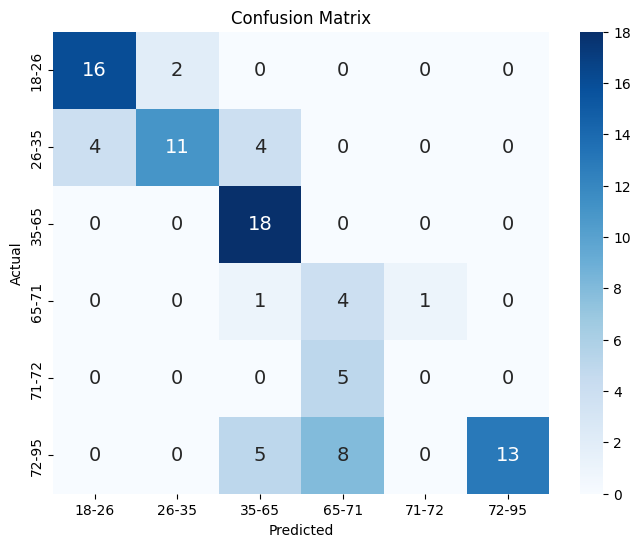

In [27]:
x_labels = [age['label'] for age in age_ranges]
plt.figure(figsize=(8, 6))
sns.heatmap(arr_confusion_matrix, cmap='Blues', annot_kws={'size': 14},
 xticklabels=x_labels, yticklabels=x_labels, fmt='d', annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig(f'/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_7_SMOTE_seq_test_set_confusion_matrix_{testing_size}.png')
# save as svg
plt.savefig(f'/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_7_SMOTE_seq_test_set_confusion_matrix_{testing_size}.svg')
plt.show()

In [28]:
eigth_bins_test = pd.read_csv("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Data/RNAseq_Combat_z_score_Test_set.csv")
eigth_bins_test.head()

,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,ENSG00000001167.14,...,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Age,Status,Experiment,Age.1,Sample,Sex
0,-0.022233,-0.024446,-0.006216,-0.024515,-0.023171,-0.023202,-0.019452,-0.021846,-0.022867,-0.023905,...,-0.024472,-0.024526,-0.023199,-0.024432,24.0,Healthy,GSE157585,24.0,SRR12604218,NaN
1,-0.023307,-0.025360,-0.006206,-0.022286,-0.022653,-0.024454,-0.018532,-0.020077,-0.018804,-0.020995,...,-0.025252,-0.025311,-0.024447,-0.025087,18.0,Healthy,GSE167186,18.0,SRR13759023,NaN
2,-0.027950,-0.030171,-0.006227,-0.026315,-0.025683,-0.028757,-0.020073,-0.022860,-0.020748,-0.024276,...,-0.029934,-0.029985,-0.022886,-0.029776,23.0,Healthy,GSE167186,23.0,SRR13759025,NaN
3,-0.024681,-0.028953,-0.002464,-0.027633,-0.027815,-0.027149,-0.019945,-0.025554,-0.020408,-0.027101,...,-0.028774,-0.028772,-0.027571,-0.028812,26.4,untrained,GSE60590,26.4,SRR1555206,female
4,-0.021846,-0.026700,0.003155,-0.022868,-0.023732,-0.026121,-0.013602,-0.018935,-0.015076,-0.019944,...,-0.026722,-0.026784,-0.025465,-0.026577,71.0,Healthy,GSE157585,71.0,SRR12604184,NaN


In [29]:
age_ranges_list=[18, 26, 35, 65, 71,72, 95]
age_ranges = fs.get_age_distribution(eigth_bins_test["Age"], age_ranges=age_ranges_list)
age_ranges

[{'label': '18-26', 'range': (18, 26), 'count': 13},
 {'label': '26-35', 'range': (26, 35), 'count': 23},
 {'label': '35-65', 'range': (35, 65), 'count': 17},
 {'label': '65-71', 'range': (65, 71), 'count': 9},
 {'label': '71-72', 'range': (71, 72), 'count': 25},
 {'label': '72-95', 'range': (72, 95), 'count': 21}]

In [30]:
X_test_untoached = eigth_bins_test.drop(columns=["Age"])
X_test_untoached.drop(columns=["Experiment", "Sample", "Age.1", "Status", "Sex"], inplace=True)
y_test_untoached = eigth_bins_test["Age"]
seq_z_test = eigth_bins_test["Experiment"]

In [31]:
X_test_untoached.columns

Index(['ENSG00000000003.14', 'ENSG00000000005.5', 'ENSG00000000419.12',
       'ENSG00000000457.13', 'ENSG00000000460.16', 'ENSG00000000938.12',
       'ENSG00000000971.15', 'ENSG00000001036.13', 'ENSG00000001084.11',
       'ENSG00000001167.14',
       ...
       'ENSG00000285458.1', 'ENSG00000285470.1', 'ENSG00000285471.1',
       'ENSG00000285472.1', 'ENSG00000285476.1', 'ENSG00000285480.1',
       'ENSG00000285491.1', 'ENSG00000285505.1', 'ENSG00000285508.1',
       'ENSG00000285509.1'],
      dtype='object', length=34505)

In [32]:
seq_z_test = pd.DataFrame(seq_z_test)
seq_z_test.columns = ["Experiment"]

In [33]:
# Make predictions
y_pred = seq_regressor.predict(X_test_untoached)

# Evaluate mean squared error
seq_mse = mean_squared_error(y_test_untoached, y_pred)
seq_results = pd.DataFrame({'Actual': y_test_untoached, 'Predicted': y_pred})
seq_mse

66.91137108269366

/tmp/ipykernel_112440/1741262349.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='Actual', y='Predicted', data=seq_results, palette='Set1', alpha=0.8, edgecolor='w')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


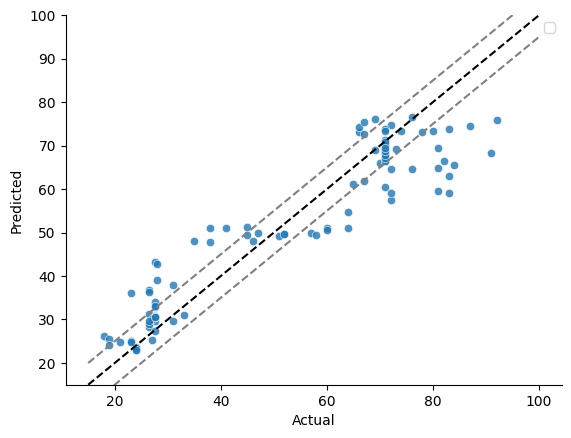

In [34]:
# Your existing scatter plot code
sns.scatterplot(x='Actual', y='Predicted', data=seq_results, palette='Set1', alpha=0.8, edgecolor='w')

# Plotting the diagonal line
plt.plot([15, 100], [15, 100], color='black', linestyle='--')

# Plotting lines parallel to the diagonal line
plt.plot([15, 100], [20, 105], color='gray', linestyle='--')
plt.plot([15, 100], [10, 95], color='gray', linestyle='--')

# Customizing the plot
plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.gca().set_ylim(bottom=15, top=100)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.savefig(f'/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_7_SMOTE_seq_untouched_set_scatterplot_{testing_size}.png')
plt.show()

In [35]:
from importlib import reload
reload(m)

<module 'model' from '/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/model.py'>

     Actual  Predicted Experiment
0      24.0  23.318949  GSE157585
1      18.0  26.264195  GSE167186
2      23.0  25.042956  GSE167186
3      26.4  36.713805   GSE60590
4      71.0  66.987953  GSE157585
..      ...        ...        ...
103    71.0  70.781076  GSE157585
104    23.0  24.866281  GSE167186
105    72.0  64.658390  GSE164471
106    71.0  69.487966  GSE157585
107    71.0  73.380437  GSE167186

[108 rows x 3 columns]


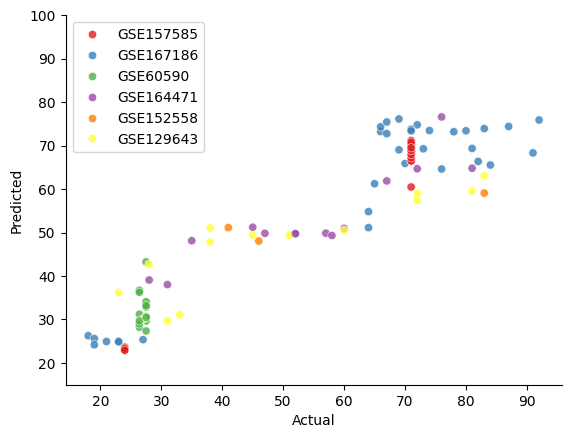

     Actual  Predicted Experiment
0      24.0  23.318949  GSE157585
1      18.0  26.264195  GSE167186
2      23.0  25.042956  GSE167186
3      26.4  36.713805   GSE60590
4      71.0  66.987953  GSE157585
..      ...        ...        ...
103    71.0  70.781076  GSE157585
104    23.0  24.866281  GSE167186
105    72.0  64.658390  GSE164471
106    71.0  69.487966  GSE157585
107    71.0  73.380437  GSE167186

[108 rows x 3 columns]


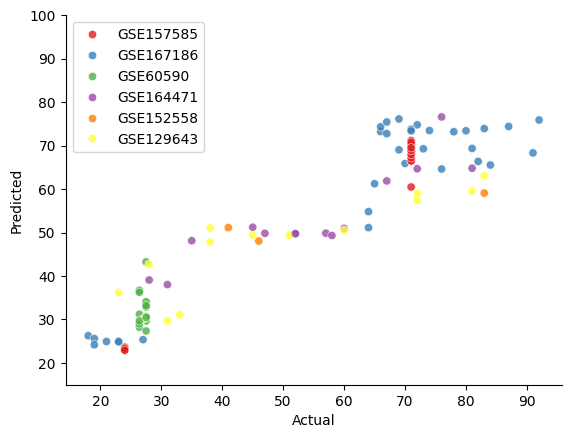

In [36]:
m.output_directory = "/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/Catboost"
m.plot_results(results=seq_results, labels=seq_z_test, save=True, save_output=f"catboost_regression_smote_untoached_{testing_size}.png")
m.plot_results(results=seq_results, labels=seq_z_test, save=True, save_output=f"catboost_regression_smote_untoached_{testing_size}.svg")

In [37]:
testing_size

'40'

In [38]:
c_y_test = pd.Series(y_test_untoached).apply(lambda x: divide.assign_age_group(x, age_ranges))
c_y_pred = pd.Series(y_pred).apply(lambda x: divide.assign_age_group(x, age_ranges))
arr_confusion_matrix = confusion_matrix(c_y_test, c_y_pred)
arr_confusion_matrix

array([[11,  1,  1,  0,  0,  0],
       [ 1, 16,  6,  0,  0,  0],
       [ 0,  0, 17,  0,  0,  0],
       [ 0,  0,  2,  2,  0,  5],
       [ 0,  0,  1, 21,  1,  2],
       [ 0,  0,  8,  5,  0,  8]])

In [39]:
acu = accuracy_score(c_y_test, c_y_pred)
acu

0.5092592592592593

In [40]:
mcc = matthews_corrcoef(c_y_test, c_y_pred)
mcc

0.4542533038198583

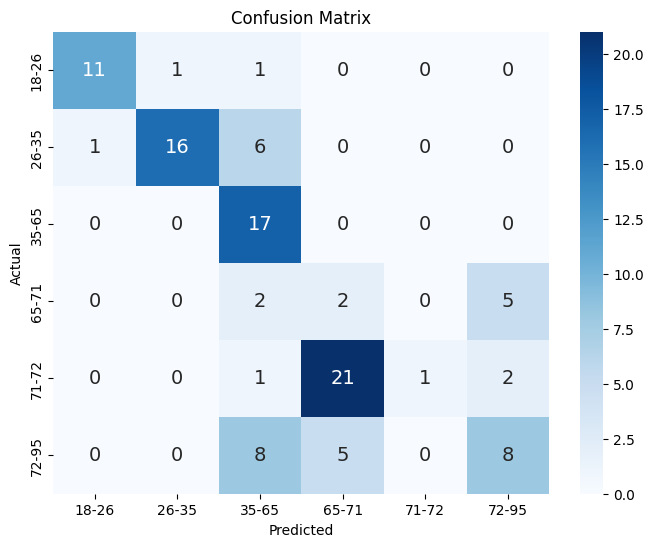

In [41]:
x_labels = [age['label'] for age in age_ranges]
plt.figure(figsize=(8, 6))
sns.heatmap(arr_confusion_matrix, cmap='Blues', annot_kws={'size': 14},
 xticklabels=x_labels, yticklabels=x_labels, fmt='d', annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig(f"RNAseq_catboost_untoached_test_set_confusion_matrix_{testing_size}.png")
plt.show()

In [42]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_auc_score
import numpy as np

# Calculate AUC
# Assuming y_test and y_pred are appropriate for AUC calculation (e.g., binary classification)
# auc = roc_auc_score(y_test, y_pred)

# Calculate MSE
mse = mean_squared_error(y_test_untoached, y_pred)

# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate MAE
mae = mean_absolute_error(y_test_untoached, y_pred)

# Calculate R2
r2 = r2_score(y_test_untoached, y_pred)

print("Metrics:")
# print("AUC:", auc)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)


Metrics:
MSE: 66.91137108269366
RMSE: 8.179937107502335
MAE: 6.035497319480335
R2: 0.8663528626565762


In [43]:
explainer = shap.Explainer(seq_regressor, X_test)
shap_values = explainer.shap_values(X_test, check_additivity=False)
importance = seq_regressor.get_feature_importance()
feature_imporance_df = pd.DataFrame(importance, index=X_test.columns, columns=["importance"])
feature_imporance_df=feature_imporance_df[feature_imporance_df["importance"] > 0]
feature_imporance_df = feature_imporance_df.sort_values(by="importance", ascending=False)
feature_imporance_df

,importance
ENSG00000203685.9,1.953484e+01
ENSG00000066855.15,9.205338e+00
ENSG00000035664.11,6.349829e+00
ENSG00000103264.17,4.661575e+00
ENSG00000164879.6,4.181707e+00
...,...
ENSG00000089351.14,6.833475e-06
ENSG00000212907.2,4.493094e-06
ENSG00000131876.16,4.204542e-07
ENSG00000119414.11,2.799330e-07


In [44]:
feature_imporance_path = f"/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_2_7b_feature_importance_{testing_size}.csv"
feature_imporance_df.to_csv(feature_imporance_path)

In [45]:
feature_imporance_df.head(50)


,importance
ENSG00000203685.9,19.534839
ENSG00000066855.15,9.205338
ENSG00000035664.11,6.349829
ENSG00000103264.17,4.661575
ENSG00000164879.6,4.181707
ENSG00000167323.11,3.817382
ENSG00000100813.14,2.817629
ENSG00000099783.11,2.654109
ENSG00000262855.1,2.546616
ENSG00000285043.1,2.538916


In [46]:
ensembl_list_file = "/home/karen/Documents/phd/Resources/ensmbl_list.csv"
ensembl_list = pd.read_csv(ensembl_list_file)

In [47]:
# remove after the point in all rows of feature_imporance_df
feature_imporance_df.index = feature_imporance_df.index.str.split(".").str[0]


In [48]:
# Create a dictionary for mapping ensembl to geneSymbol
ensembl_to_gene = dict(zip(ensembl_list["ensembl"], ensembl_list["geneSymbol"]))

# Replace the index of feature_importance_df
feature_imporance_df.index = feature_imporance_df.index.map(lambda x: ensembl_to_gene.get(x, x))
feature_imporance_df.head()

,importance
STUM,19.534839
MTFR1,9.205338
DAPK2,6.349829
FBXO31,4.661575
CA3,4.181707


In [49]:
X_test.rename(columns=lambda x: x.split(".")[0], inplace=True)

In [50]:
X_test = X_test.rename(columns=lambda x: ensembl_to_gene.get(x, x))


In [51]:
shap_df = pd.DataFrame(shap_values, columns=X_test.columns)
shap_df
# Save the DataFrame to a CSV file
shap_df.to_csv(f"shap_values_by_gene_Catboost_{testing_size}_extended.csv", index=False)

In [52]:
shap_values_2 = explainer(X_test, check_additivity=False)


In [53]:
X_test

,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,...,AC093827.5,AC010977.1,AC007846.2,AC134980.5,AC139491.7,AC021097.2,AC135068.11,AC010616.2,AL034430.1,AP000646.1
70,-0.019559,-0.021677,-0.006265,-0.020747,-0.020142,-0.022337,-0.018214,-0.016652,-0.017161,-0.019363,...,-0.018020,-0.021758,-0.021692,-0.021746,-0.021738,-0.021448,-0.021700,-0.021765,-0.019581,-0.021654
99,-0.020607,-0.022886,-0.003047,-0.021487,-0.022345,-0.022642,-0.018322,-0.020086,-0.019891,-0.020982,...,-0.021350,-0.023138,-0.022967,-0.023111,-0.023049,-0.022419,-0.023066,-0.023134,-0.021574,-0.023063
207,-0.027061,-0.030928,-0.004908,-0.027644,-0.027110,-0.030264,-0.018874,-0.024771,-0.021910,-0.025345,...,-0.024632,-0.031108,-0.031165,-0.031117,-0.031037,-0.030354,-0.031122,-0.031088,-0.027344,-0.030752
197,-0.023338,-0.026408,-0.003811,-0.024484,-0.025190,-0.026411,-0.022646,-0.023733,-0.023297,-0.024025,...,-0.023125,-0.026471,-0.026494,-0.026479,-0.026478,-0.026102,-0.026465,-0.026490,-0.023550,-0.026463
103,-0.024846,-0.025275,-0.001524,-0.023763,-0.023341,-0.024959,-0.019654,-0.021975,-0.019969,-0.022371,...,-0.020307,-0.025320,-0.025166,-0.025292,-0.025220,-0.025181,-0.025295,-0.025327,-0.020465,-0.025131
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,-0.025841,-0.031817,-0.006702,-0.027593,-0.028574,-0.030229,-0.020735,-0.023238,-0.020171,-0.026093,...,-0.021023,-0.031605,-0.031447,-0.031591,-0.031411,-0.030523,-0.031536,-0.031584,-0.027900,-0.031380
158,-0.030635,-0.035146,-0.006954,-0.030257,-0.031095,-0.034248,-0.029421,-0.028509,-0.018757,-0.025599,...,-0.028968,-0.035021,-0.035189,-0.035032,-0.035112,-0.034177,-0.035107,-0.035000,-0.030326,-0.034834
54,-0.022018,-0.024036,-0.007546,-0.022607,-0.022214,-0.023516,-0.021488,-0.021015,-0.019893,-0.022751,...,-0.021328,-0.024045,-0.023875,-0.024061,-0.023824,-0.023425,-0.024058,-0.024051,-0.023023,-0.023776
94,-0.024500,-0.027143,-0.004006,-0.025770,-0.025362,-0.026623,-0.018581,-0.023744,-0.023072,-0.024258,...,-0.025000,-0.027169,-0.027098,-0.027139,-0.027122,-0.026468,-0.027183,-0.027163,-0.025482,-0.027166


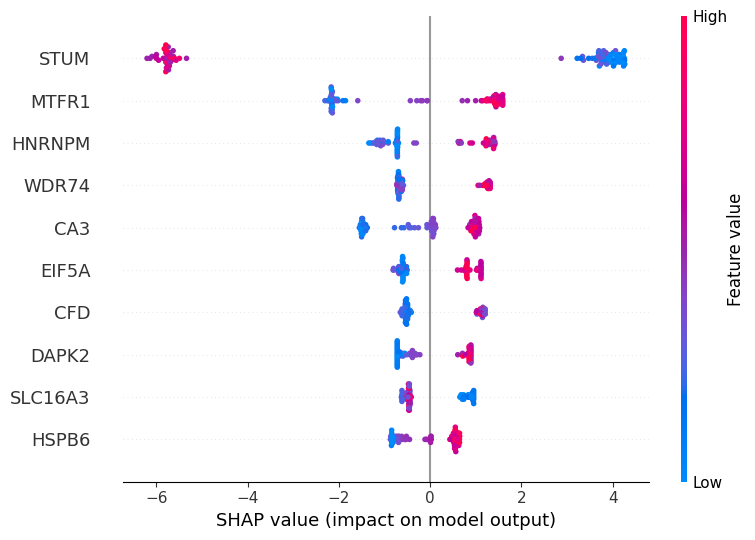

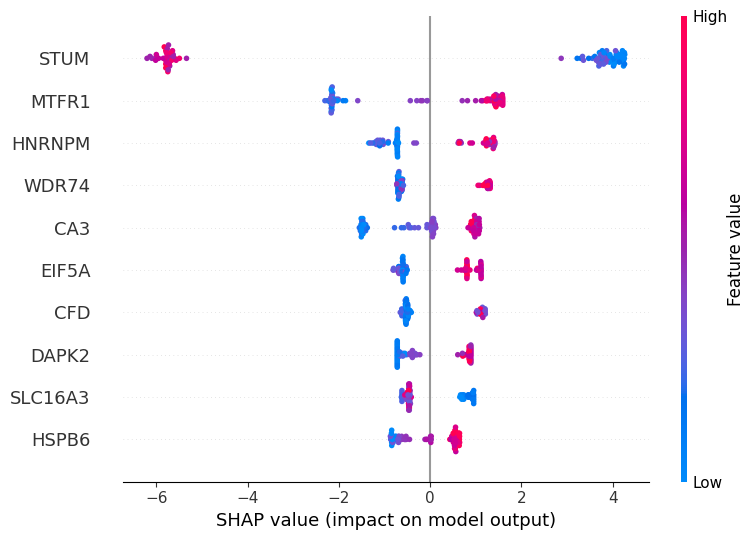

In [54]:
shap.summary_plot(shap_values, X_test, max_display=10)
# save the plot as svg
shap.summary_plot(shap_values, X_test, max_display=10, show=False)
plt.savefig(f"Results/shap_summary_plot_{testing_size}_catboost.svg")

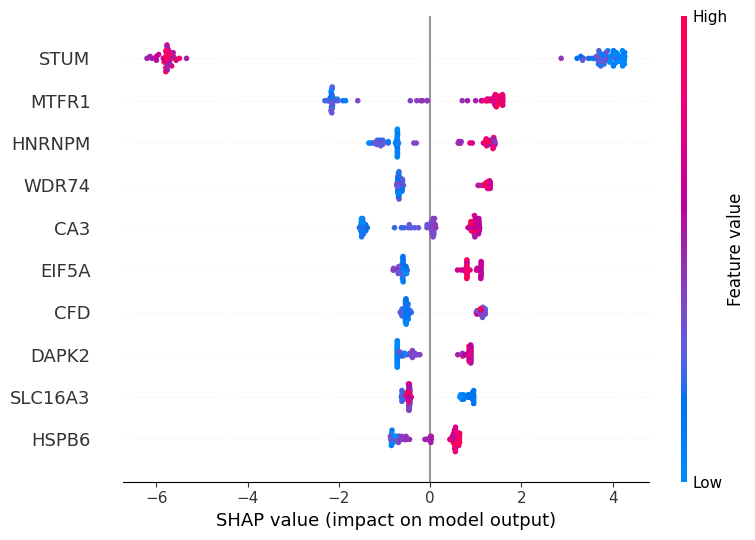

In [55]:
import matplotlib.pyplot as pl
shap.summary_plot(shap_values, X_test, max_display=10, show=False)
pl.savefig(f"shap_summary_{testing_size}_catboost.svg") #.png,.pdf will also support here


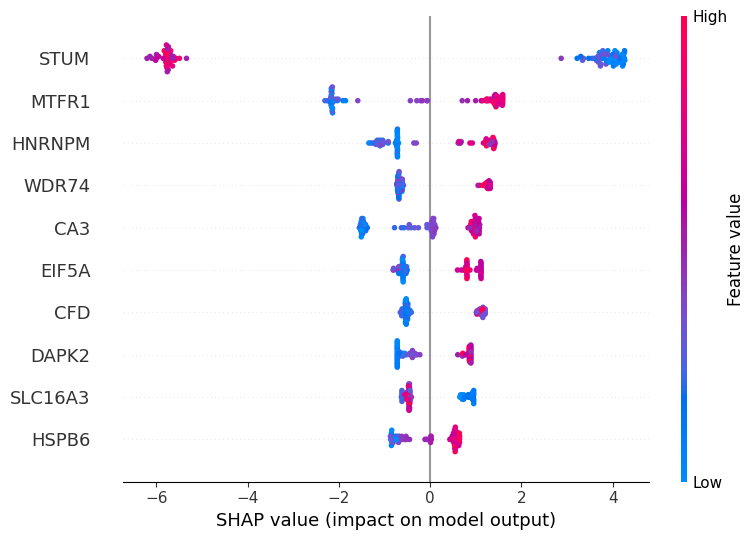

In [56]:
shap.summary_plot(shap_values_2, X_test, max_display=10)


Sample 6
 Actual             71.0
Predicted     68.992134
Experiment    GSE157585
Name: 6, dtype: object


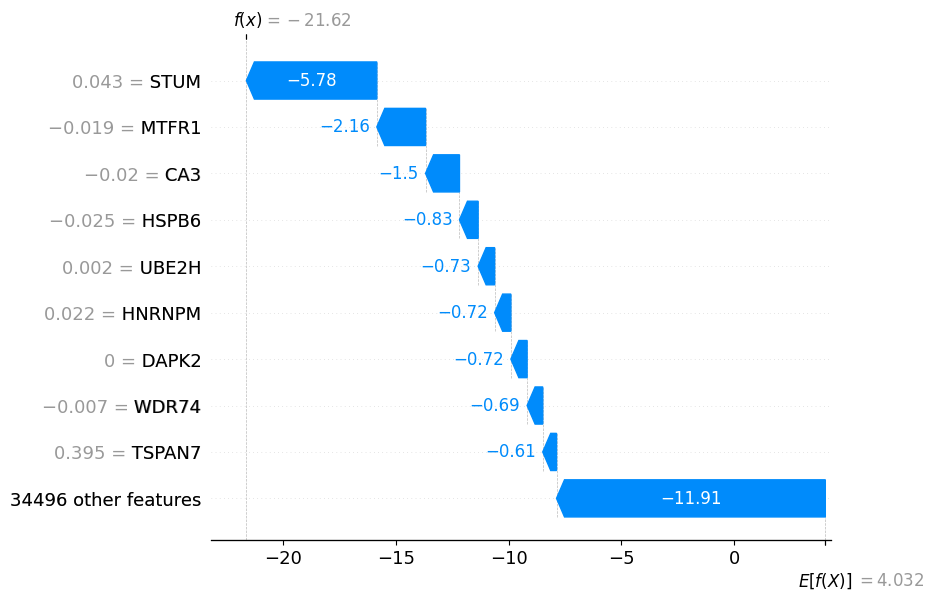

<Figure size 640x480 with 0 Axes>

In [57]:
index=6
title = f"Sample {index}\n {seq_results.iloc[index]}"

print(title)
shap.plots.waterfall(shap_values_2[index], show=True)
# save plot
plt.savefig(f"Results/shap_waterfall_plot_{testing_size}_catboost.svg")




In [58]:
shap_values

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [59]:
explainer.expected_value

4.031998232835489

In [60]:
mcc = matthews_corrcoef(c_y_test, c_y_pred)
mcc

0.4542533038198583

In [61]:
auc = accuracy_score(c_y_test, c_y_pred)
auc

0.5092592592592593

In [62]:
reload(gtg)

<module 'getting_threshold_genes' from '/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/getting_threshold_genes.py'>

In [63]:
# Elbow and Inflexion point
rn_df = gtg.get_gene_rank(feature_imporance_path)
rn_df.to_csv(f"Results/feature_selection/RNAseq/feature_importance_smote_catboost_7b_gene_ranking_{testing_size}.csv")
top_df = gtg.get_df(feature_imporance_path)
top_df.to_csv(f"Results/feature_selection/RNAseq/feature_importance_smote_catboost_7b_top_genes_inflexion_{testing_size}.csv")

 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  5 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
2.5466164630787933


/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/getting_threshold_genes.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if gene_rank_df.iloc[0][1] == "coef":
/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/getting_threshold_genes.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if gene_rank_df.iloc[0][1] == "coef":
/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.11/site-packages/pandas/core/indexes/base.py:945: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*new_inputs, **kwargs)
/home/karen/

In [64]:
top_df

,Ensembl,coef,abs_coef
0,ENSG00000203685.9,19.534839,19.534839
1,ENSG00000066855.15,9.205338,9.205338
2,ENSG00000035664.11,6.349829,6.349829
3,ENSG00000103264.17,4.661575,4.661575
4,ENSG00000164879.6,4.181707,4.181707
5,ENSG00000167323.11,3.817382,3.817382
6,ENSG00000100813.14,2.817629,2.817629
7,ENSG00000099783.11,2.654109,2.654109


In [65]:
top_df = gtg.get_df(feature_imporance_path, inflexion=False)
top_df.to_csv(f"Results/feature_selection/RNAseq/feature_importance_smote_catboost_7b_top_genes_elbow_{testing_size}.csv")

2.5466164630787933


/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/getting_threshold_genes.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if gene_rank_df.iloc[0][1] == "coef":


In [66]:
top_df

,Ensembl,coef,abs_coef
0,ENSG00000203685.9,19.534839,19.534839
1,ENSG00000066855.15,9.205338,9.205338
2,ENSG00000035664.11,6.349829,6.349829
3,ENSG00000103264.17,4.661575,4.661575
4,ENSG00000164879.6,4.181707,4.181707
5,ENSG00000167323.11,3.817382,3.817382
6,ENSG00000100813.14,2.817629,2.817629
7,ENSG00000099783.11,2.654109,2.654109
